In [2]:
import os
import csv
import random
import json
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter, defaultdict
from tqdm import tqdm
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
import joblib

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


# Configuration

In [3]:
DATA_ROOT  = "/kaggle/input/datasets/aligamalllll/adniiiiiiiiiii/adni_nifti_preprocessed"
OUTPUT_DIR = "/kaggle/working/preprocessed"
CKPT_DIR   = "/kaggle/working/checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)

IMAGE_SIZE    = 224
N_FOLDS       = 5
BATCH_SIZE    = 32
TEST_RATIO    = 0.15

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

VALID_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}

CLASS_NAMES = sorted([
    d for d in os.listdir(DATA_ROOT)
    if os.path.isdir(os.path.join(DATA_ROOT, d))
])
print(f"Classes found: {CLASS_NAMES}")

Classes found: ['AD', 'CN', 'MCI']


# Step 1 — Build Patient Map & Leakage Check

In [4]:
patient_classes = defaultdict(set)
patient_slices  = defaultdict(list)

for cls in CLASS_NAMES:
    cls_dir = os.path.join(DATA_ROOT, cls)
    if not os.path.isdir(cls_dir):
        print(f"[WARNING] Missing class folder: {cls_dir}")
        continue
    for patient_id in os.listdir(cls_dir):
        patient_dir = os.path.join(cls_dir, patient_id)
        if not os.path.isdir(patient_dir):
            continue
        slices = [
            os.path.join(patient_dir, f)
            for f in os.listdir(patient_dir)
            if os.path.splitext(f)[1].lower() in VALID_EXTS
        ]
        if slices:
            patient_classes[patient_id].add(cls)
            patient_slices[(patient_id, cls)].extend(slices)

print(f"Total unique patients: {len(patient_classes)}")

leakage_patients = {
    pid: classes
    for pid, classes in patient_classes.items()
    if len(classes) > 1
}

print(f"\n{'='*55}")
print(f"  LEAKAGE CHECK")
print(f"{'='*55}")
if leakage_patients:
    print(f"  Patients in multiple classes (EXCLUDED): {len(leakage_patients)}")
    for pid, classes in sorted(leakage_patients.items()):
        print(f"    {pid}  ->  {sorted(classes)}")
else:
    print("  No patients in multiple classes. Dataset is clean.")

clean_patients = {
    pid: list(classes)[0]
    for pid, classes in patient_classes.items()
    if pid not in leakage_patients
}
print(f"\n  Patients kept    : {len(clean_patients)}")
print(f"  Patients excluded: {len(leakage_patients)}")

Total unique patients: 320

  LEAKAGE CHECK
  No patients in multiple classes. Dataset is clean.

  Patients kept    : 320
  Patients excluded: 0


# Step 2 — Hold-Out Test Set (Patient-Level, Stratified)

In [5]:
class_patients = defaultdict(list)
for pid, cls in clean_patients.items():
    class_patients[cls].append(pid)

for cls in CLASS_NAMES:
    random.shuffle(class_patients[cls])

test_patients     = []
trainval_patients = []

print(f"{'='*55}")
print(f"  HOLD-OUT TEST SET (stratified by class)")
print(f"{'='*55}")

for cls in CLASS_NAMES:
    pids   = class_patients[cls]
    n_test = max(1, int(len(pids) * TEST_RATIO))
    test_patients.extend(pids[:n_test])
    trainval_patients.extend(pids[n_test:])
    print(f"  {cls}: {len(pids)} total  |  test={n_test}  |  train+val pool={len(pids)-n_test}")

assert not (set(test_patients) & set(trainval_patients)), "Test/trainval overlap!"
print(f"\n  Test patients     : {len(test_patients)}")
print(f"  Train+Val patients: {len(trainval_patients)}")
print(f"  Total             : {len(test_patients)+len(trainval_patients)}")

test_entries = []
for pid in test_patients:
    cls   = clean_patients[pid]
    label = CLASS_NAMES.index(cls)
    for path in patient_slices[(pid, cls)]:
        test_entries.append((path, label, pid))

print(f"  Test slices       : {len(test_entries)}")

  HOLD-OUT TEST SET (stratified by class)
  AD: 54 total  |  test=8  |  train+val pool=46
  CN: 88 total  |  test=13  |  train+val pool=75
  MCI: 178 total  |  test=26  |  train+val pool=152

  Test patients     : 47
  Train+Val patients: 273
  Total             : 320
  Test slices       : 1261


# Step 3 — Preprocess & Save All Slices to Disk

In [6]:
if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)
os.makedirs(OUTPUT_DIR, exist_ok=True)

all_entries = []
for pid, cls in clean_patients.items():
    label = CLASS_NAMES.index(cls)
    for path in patient_slices[(pid, cls)]:
        all_entries.append((path, label, pid))

fname_counts = {}

def preprocess_and_save(entries, desc="Saving"):
    for path, label, pid in tqdm(entries, desc=desc):
        cls_name = CLASS_NAMES[label]
        out_dir  = os.path.join(OUTPUT_DIR, cls_name)
        os.makedirs(out_dir, exist_ok=True)

        base  = os.path.splitext(os.path.basename(path))[0]
        key   = f"{pid}_{base}"
        fname_counts[key] = fname_counts.get(key, 0) + 1
        suffix   = f"_dup{fname_counts[key]}" if fname_counts[key] > 1 else ""
        out_path = os.path.join(out_dir, f"{key}{suffix}.pt")

        if not os.path.exists(out_path):
            img    = Image.open(path).convert("L")
            img    = img.resize((IMAGE_SIZE, IMAGE_SIZE))
            tensor = transforms.ToTensor()(img)
            tensor = (tensor * 255).byte().repeat(3, 1, 1)
            torch.save(tensor, out_path)

preprocess_and_save(all_entries, desc="Preprocessing all slices")
print(f"Done. {len(all_entries)} slices saved to {OUTPUT_DIR}")

pt_lookup = {}
for cls in CLASS_NAMES:
    cls_dir = os.path.join(OUTPUT_DIR, cls)
    if not os.path.isdir(cls_dir):
        continue
    for fname in os.listdir(cls_dir):
        if fname.endswith(".pt"):
            stem = fname[:-3]
            pt_lookup[stem] = os.path.join(cls_dir, fname)

print(f"pt_lookup built: {len(pt_lookup)} entries")

Preprocessing all slices: 100%|██████████| 8512/8512 [00:46<00:00, 182.40it/s]

Done. 8512 slices saved to /kaggle/working/preprocessed
pt_lookup built: 8512 entries


# Step 4 — Dataset Class

No augmentation here — freeze features must be **deterministic** so the SVM sees consistent feature vectors.

In [7]:
normalize = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)

class SliceDataset(Dataset):
    """
    Loads preprocessed .pt tensors.
    Augmentation is disabled for the freeze-feature SVM pipeline:
    deterministic features are required for consistent SVM training.
    patient_id is returned so patient-level aggregation can be done at eval time.
    """
    def __init__(self, entries):
        self.samples = []
        for path, label, pid in entries:
            cls_name = CLASS_NAMES[label]
            base     = os.path.splitext(os.path.basename(path))[0]
            key      = f"{pid}_{base}"

            if key in pt_lookup:
                self.samples.append((pt_lookup[key], label, pid))
            else:
                for dup_idx in range(2, 50):
                    dup_key = f"{key}_dup{dup_idx}"
                    if dup_key in pt_lookup:
                        self.samples.append((pt_lookup[dup_key], label, pid))
                        break

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        pt_path, label, pid = self.samples[idx]
        tensor = torch.load(pt_path, weights_only=True).float() / 255.0
        return normalize(tensor), label, pid

    def get_labels(self): return [s[1] for s in self.samples]

print("SliceDataset class defined.")

SliceDataset class defined.


# Step 5 — Model: VGG19 Freeze Feature Extractor + SVM

Exactly as in **Naz et al. (2022)**:

| Component | Detail |
|---|---|
| Backbone | VGG19, pre-trained on ImageNet |
| Freeze strategy | **All layers frozen** — zero weight updates |
| Feature layer | `classifier[0]` → **FC6** (4096-dim, pre-ReLU) |
| Classifier | RBF-kernel **SVM** per binary scenario |
| Scenarios | MCI vs AD · AD vs CN · MCI vs CN |

The convolutional layers act as a fixed off-the-shelf feature extractor.
Features are StandardScaler-normalised before SVM fitting.

In [8]:
def build_vgg19_extractor():
    """
    VGG19 pre-trained on ImageNet with ALL parameters frozen.
    Used as a fixed feature extractor — no fine-tuning.
    Matches the paper's freeze-features transfer learning approach.
    """
    model = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1)
    for param in model.parameters():
        param.requires_grad = False
    model.eval()
    return model

extractor = build_vgg19_extractor().to(device)

total_params     = sum(p.numel() for p in extractor.parameters())
trainable_params = sum(p.numel() for p in extractor.parameters() if p.requires_grad)
print(f"VGG19 loaded — ImageNet weights.")
print(f"  Total parameters    : {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}  (0 — all frozen ✓)")
print(f"  Feature layer       : classifier[0]  →  FC6  (4096-dim, pre-ReLU)")

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:02<00:00, 201MB/s] 


VGG19 loaded — ImageNet weights.
  Total parameters    : 143,667,240
  Trainable parameters: 0  (0 — all frozen ✓)
  Feature layer       : classifier[0]  →  FC6  (4096-dim, pre-ReLU)


# Step 6 — Feature Extraction Utility

A forward hook on `model.classifier[0]` (the raw linear FC6 layer, **pre-ReLU**)
captures the 4096-dim vector for every image — exactly the layer the paper names
as its best-performing feature source for VGG19.

In [9]:
def extract_fc6_features(loader, model, desc="Extracting FC6"):
    features_list = []
    labels_list   = []
    pids_list     = []
    fc6_out       = {}

    def hook_fn(module, input, output):
        fc6_out['feat'] = output.detach().cpu()

    hook = model.classifier[0].register_forward_hook(hook_fn)
    model.eval()

    with torch.no_grad():
        for images, labels, pids in tqdm(loader, desc=desc, leave=False):
            images = images.to(device, non_blocking=True)
            _      = model(images)
            features_list.append(fc6_out['feat'].numpy())
            labels_list.extend(labels.numpy().tolist())
            pids_list.extend(list(pids))

    hook.remove()
    return np.vstack(features_list), np.array(labels_list), pids_list

def patient_level_eval_svm(X_sc, y_true, pids, svm):
    probs = svm.predict_proba(X_sc)

    patient_probs  = defaultdict(list)
    patient_labels = {}
    for prob, label, pid in zip(probs, y_true, pids):
        patient_probs[pid].append(prob)
        patient_labels[pid] = int(label)

    all_true, all_pred = [], []
    for pid, probs_list in patient_probs.items():
        avg_prob = np.mean(probs_list, axis=0)
        all_true.append(patient_labels[pid])
        all_pred.append(int(np.argmax(avg_prob)))

    acc = np.mean(np.array(all_true) == np.array(all_pred))
    return acc, all_true, all_pred

print("Feature extraction & patient-level SVM eval utilities defined.")

Feature extraction & patient-level SVM eval utilities defined.


# Step 7 — K-Fold Cross-Validation (Train+Val Pool)

In [10]:
import torch._dynamo
torch._dynamo.config.suppress_errors = True

trainval_by_class = defaultdict(list)
for pid in trainval_patients:
    trainval_by_class[clean_patients[pid]].append(pid)

for cls in CLASS_NAMES:
    random.shuffle(trainval_by_class[cls])

fold_results    = {cls: [] for cls in CLASS_NAMES}
all_fold_svms   = {cls: [] for cls in CLASS_NAMES}
all_fold_scalers= {cls: [] for cls in CLASS_NAMES}

for pos_class_idx, pos_name in enumerate(CLASS_NAMES):
    print(f"\n{'='*65}")
    print(f"  {pos_name} vs REST  —  {N_FOLDS}-Fold Cross-Validation")
    print(f"{'='*65}")

    binary_names = ["REST", pos_name]

    class_folds = {}
    for cls in CLASS_NAMES:
        pids  = trainval_by_class[cls]
        folds = [pids[i::N_FOLDS] for i in range(N_FOLDS)]
        class_folds[cls] = folds

    for fold_idx in range(N_FOLDS):
        print(f"\n  --- Fold {fold_idx+1}/{N_FOLDS} ---")

        val_pids_fold = []
        for cls in CLASS_NAMES:
            val_pids_fold.extend(class_folds[cls][fold_idx])

        train_pids_fold = []
        for cls in CLASS_NAMES:
            for k, chunk in enumerate(class_folds[cls]):
                if k != fold_idx:
                    train_pids_fold.extend(chunk)

        def expand(pids):
            out = []
            for pid in pids:
                cls   = clean_patients[pid]
                label = CLASS_NAMES.index(cls)
                for path in patient_slices[(pid, cls)]:
                    out.append((path, label, pid))
            return out

        def binarize(entries):
            return [(p, 1 if l == pos_class_idx else 0, pid)
                    for p, l, pid in entries]

        train_bin = binarize(expand(train_pids_fold))
        val_bin   = binarize(expand(val_pids_fold))

        train_ds = SliceDataset(train_bin)
        val_ds   = SliceDataset(val_bin)

        pos_count = sum(1 for _, l, _ in train_bin if l == 1)
        neg_count = len(train_bin) - pos_count
        print(f"  Train slices — {pos_name}: {pos_count} | REST: {neg_count} | "
              f"Val patients: {len(val_pids_fold)}")

        if len(train_ds) == 0:
            raise RuntimeError(
                f"Fold {fold_idx+1} ({pos_name}): train_ds is empty! "
                f"Re-run Step 3 to rebuild the preprocessed cache."
            )

        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False,
                                  num_workers=4, pin_memory=True, persistent_workers=True)
        val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                                  num_workers=4, pin_memory=True, persistent_workers=True)

        # ── Extract FC6 features ───────────────────────────────────────────────
        print(f"  Extracting train features...")
        X_train, y_train, pids_train = extract_fc6_features(train_loader, extractor,
                                                              f"Fold {fold_idx+1} Train")
        print(f"  Extracting val features...")
        X_val,   y_val,   pids_val   = extract_fc6_features(val_loader,   extractor,
                                                              f"Fold {fold_idx+1} Val")

        # ── StandardScaler (fit on train only) ────────────────────────────────
        scaler   = StandardScaler()
        X_tr_sc  = scaler.fit_transform(X_train)
        X_vl_sc  = scaler.transform(X_val)

        # ── RBF-kernel SVM — exactly as in the paper ──────────────────────────
        print(f"  Training SVM...")
        svm = SVC(kernel='rbf', C=1.0, gamma='scale',
                  class_weight='balanced',
                  random_state=SEED, probability=True)
        svm.fit(X_tr_sc, y_train)

        # ── Patient-level validation accuracy ─────────────────────────────────
        pat_acc, _, _ = patient_level_eval_svm(X_vl_sc, y_val, pids_val, svm)
        print(f"  Fold {fold_idx+1} — Patient-level val acc: {pat_acc*100:.2f}%")

        fold_results[pos_name].append(pat_acc)
        all_fold_svms[pos_name].append(svm)
        all_fold_scalers[pos_name].append(scaler)

        ckpt_path = os.path.join(CKPT_DIR, f"fold{fold_idx+1}_{pos_name}_vs_rest.pkl")
        joblib.dump({'svm': svm, 'scaler': scaler}, ckpt_path)

        del train_ds, val_ds
        torch.cuda.empty_cache()

    mean_acc = np.mean(fold_results[pos_name]) * 100
    std_acc  = np.std(fold_results[pos_name])  * 100
    print(f"\n  {pos_name} vs REST — {N_FOLDS}-Fold CV Patient Acc: "
          f"{mean_acc:.2f}% ± {std_acc:.2f}%")

print("\n\nAll folds done.")


  AD vs REST  —  5-Fold Cross-Validation

  --- Fold 1/5 ---
  Train slices — AD: 950 | REST: 4808 | Val patients: 56
  Extracting train features...


  Extracting val features...


  Training SVM...
  Fold 1 — Patient-level val acc: 80.36%

  --- Fold 2/5 ---
  Train slices — AD: 982 | REST: 4809 | Val patients: 55
  Extracting train features...


  Extracting val features...


  Training SVM...
  Fold 2 — Patient-level val acc: 85.45%

  --- Fold 3/5 ---
  Train slices — AD: 977 | REST: 4839 | Val patients: 54
  Extracting train features...


...

  Training SVM...
  Fold 3 — Patient-level val acc: 61.11%

  --- Fold 4/5 ---
  Train slices — MCI: 3251 | REST: 2566 | Val patients: 54
  Extracting train features...


  Extracting val features...


  Training SVM...
  Fold 4 — Patient-level val acc: 59.26%

  --- Fold 5/5 ---
  Train slices — MCI: 3239 | REST: 2583 | Val patients: 54
  Extracting train features...


  Extracting val features...


  Training SVM...
  Fold 5 — Patient-level val acc: 61.11%

  MCI vs REST — 5-Fold CV Patient Acc: 56.83% ± 4.76%


All folds done.


# Step 8 — Weighted Ensemble Evaluation on Hold-Out Test Set (Patient-Level)

  WEIGHTED ENSEMBLE — HOLD-OUT TEST EVALUATION (Patient-Level)

  Extracting test features for AD vs REST...



  AD vs REST
    Fold 1: val_acc=80.36%  weight=0.1941
    Fold 2: val_acc=85.45%  weight=0.2064
    Fold 3: val_acc=83.33%  weight=0.2013
    Fold 4: val_acc=83.33%  weight=0.2013
    Fold 5: val_acc=81.48%  weight=0.1968

  Weighted Ensemble Test Acc (AD vs REST): 82.98%  [47 patients]
              precision    recall  f1-score   support

        REST       0.83      1.00      0.91        39
          AD       0.00      0.00      0.00         8

    accuracy                           0.83        47
   macro avg       0.41      0.50      0.45        47
weighted avg       0.69      0.83      0.75        47



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


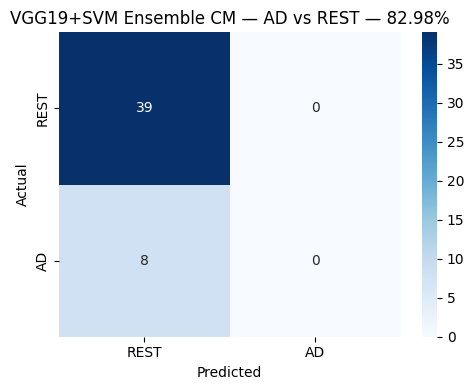


  Extracting test features for CN vs REST...



  CN vs REST
    Fold 1: val_acc=62.50%  weight=0.1795
    Fold 2: val_acc=70.91%  weight=0.2036
    Fold 3: val_acc=64.81%  weight=0.1861
    Fold 4: val_acc=72.22%  weight=0.2074
    Fold 5: val_acc=77.78%  weight=0.2234

  Weighted Ensemble Test Acc (CN vs REST): 76.60%  [47 patients]
              precision    recall  f1-score   support

        REST       0.76      1.00      0.86        34
          CN       1.00      0.15      0.27        13

    accuracy                           0.77        47
   macro avg       0.88      0.58      0.56        47
weighted avg       0.82      0.77      0.70        47



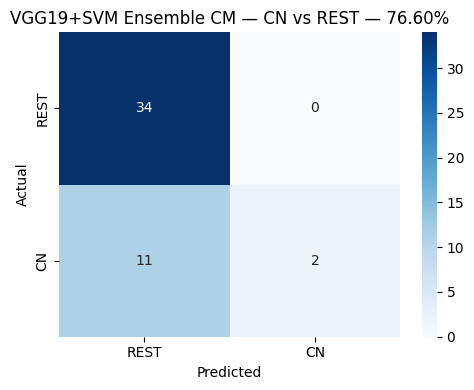


  Extracting test features for MCI vs REST...



  MCI vs REST
    Fold 1: val_acc=53.57%  weight=0.1885
    Fold 2: val_acc=49.09%  weight=0.1728
    Fold 3: val_acc=61.11%  weight=0.2151
    Fold 4: val_acc=59.26%  weight=0.2086
    Fold 5: val_acc=61.11%  weight=0.2151

  Weighted Ensemble Test Acc (MCI vs REST): 61.70%  [47 patients]
              precision    recall  f1-score   support

        REST       0.57      0.57      0.57        21
         MCI       0.65      0.65      0.65        26

    accuracy                           0.62        47
   macro avg       0.61      0.61      0.61        47
weighted avg       0.62      0.62      0.62        47



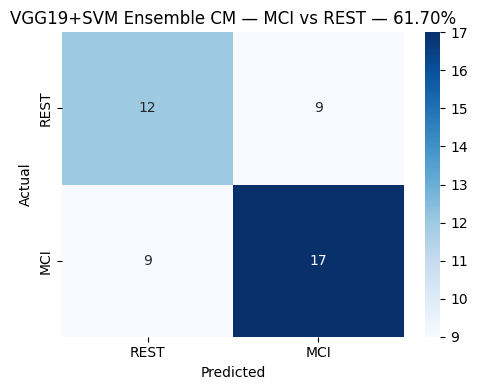

In [11]:
print(f"{'='*65}")
print(f"  WEIGHTED ENSEMBLE — HOLD-OUT TEST EVALUATION (Patient-Level)")
print(f"{'='*65}")

final_results = {}

for pos_class_idx, pos_name in enumerate(CLASS_NAMES):
    binary_names = ["REST", pos_name]

    test_bin = [
        (p, 1 if l == pos_class_idx else 0, pid)
        for p, l, pid in test_entries
    ]
    test_ds     = SliceDataset(test_bin)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=4, pin_memory=True, persistent_workers=True)

    print(f"\n  Extracting test features for {pos_name} vs REST...")
    X_test, y_test, pids_test = extract_fc6_features(test_loader, extractor,
                                                       f"{pos_name} Test")

    fold_accs    = np.array(fold_results[pos_name])
    fold_weights = fold_accs / fold_accs.sum()

    print(f"\n  {pos_name} vs REST")
    for fi, (acc, w) in enumerate(zip(fold_accs, fold_weights)):
        print(f"    Fold {fi+1}: val_acc={acc*100:.2f}%  weight={w:.4f}")

    patient_probs  = defaultdict(lambda: np.zeros(2))
    patient_labels = {}

    for fold_svm, fold_scaler, w in zip(
        all_fold_svms[pos_name],
        all_fold_scalers[pos_name],
        fold_weights
    ):
        X_te_sc = fold_scaler.transform(X_test)
        probs   = fold_svm.predict_proba(X_te_sc)

        for prob, label, pid in zip(probs, y_test, pids_test):
            patient_probs[pid]  += w * prob
            patient_labels[pid]  = int(label)

    all_true, all_pred = [], []
    for pid, wp_sum in patient_probs.items():
        all_true.append(patient_labels[pid])
        all_pred.append(int(np.argmax(wp_sum)))

    pat_acc = np.mean(np.array(all_true) == np.array(all_pred))

    print(f"\n  Weighted Ensemble Test Acc ({pos_name} vs REST): "
          f"{pat_acc*100:.2f}%  [{len(patient_probs)} patients]")
    print(classification_report(all_true, all_pred, target_names=binary_names))

    cm = confusion_matrix(all_true, all_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=binary_names, yticklabels=binary_names)
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.title(f"VGG19+SVM Ensemble CM — {pos_name} vs REST — {pat_acc*100:.2f}%")
    plt.tight_layout()
    plt.savefig(os.path.join(CKPT_DIR, f"cm_ensemble_{pos_name}_vs_rest.png"), dpi=150)
    plt.show()

    final_results[pos_name] = {
        "patient_test_acc": pat_acc,
        "cv_mean_acc":      float(np.mean(fold_accs)),
        "cv_std_acc":       float(np.std(fold_accs)),
        "fold_weights":     fold_weights.tolist(),
    }

    torch.cuda.empty_cache()

# Step 9 — Summary & Save Results

In [12]:
print(f"\n{'='*65}")
print(f"  FINAL SUMMARY — VGG19 FREEZE + SVM WEIGHTED ENSEMBLE")
print(f"{'='*65}")
print(f"  {'Class':<8} {'CV Acc (mean±std)':<24} {'Ensemble Test Acc (patient-level)'}")
print(f"  {'-'*65}")

for cls, res in final_results.items():
    cv_str   = f"{res['cv_mean_acc']*100:.2f}% ± {res['cv_std_acc']*100:.2f}%"
    test_str = f"{res['patient_test_acc']*100:.2f}%"
    print(f"  {cls:<8} {cv_str:<24} {test_str}")

csv_path = os.path.join(CKPT_DIR, "results_vgg19_svm_weighted_ensemble.csv")
with open(csv_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=[
        "class", "cv_mean_acc_%", "cv_std_%", "ensemble_test_acc_%", "fold_weights"
    ])
    writer.writeheader()
    for cls, res in final_results.items():
        writer.writerow({
            "class":               cls,
            "cv_mean_acc_%":       round(res["cv_mean_acc"] * 100, 2),
            "cv_std_%":            round(res["cv_std_acc"]  * 100, 2),
            "ensemble_test_acc_%": round(res["patient_test_acc"] * 100, 2),
            "fold_weights":        str([round(w, 4) for w in res["fold_weights"]]),
        })

print(f"\n  Results saved -> {csv_path}")
print(f"  SVM checkpoints  -> {CKPT_DIR}/fold*_<class>_vs_rest.pkl")


  FINAL SUMMARY — VGG19 FREEZE + SVM WEIGHTED ENSEMBLE
  Class    CV Acc (mean±std)        Ensemble Test Acc (patient-level)
  -----------------------------------------------------------------
  AD       82.79% ± 1.75%           82.98%
  CN       69.64% ± 5.45%           76.60%
  MCI      56.83% ± 4.76%           61.70%

  Results saved -> /kaggle/working/checkpoints/results_vgg19_svm_weighted_ensemble.csv
  SVM checkpoints  -> /kaggle/working/checkpoints/fold*_<class>_vs_rest.pkl


  0%|          | 0/1000 [00:00<?, ?it/s]

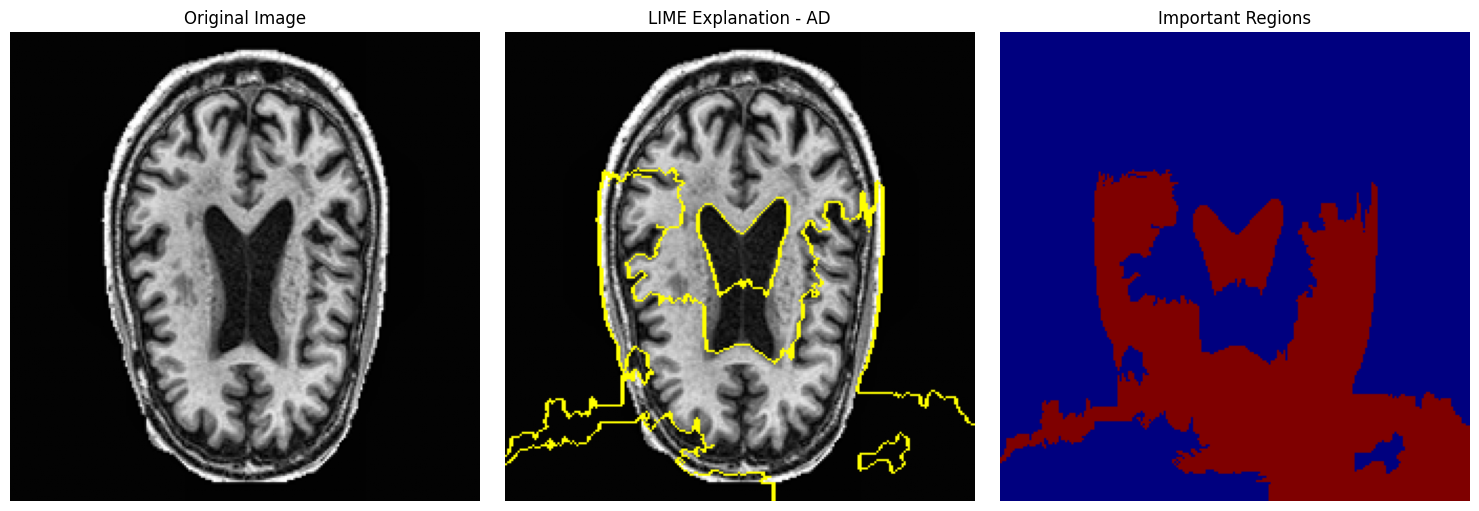

In [13]:
!pip install lime

import lime
from lime import lime_image
from lime.wrappers.scikit_image import SegmentationAlgorithm
from skimage.segmentation import mark_boundaries
import matplotlib.pyplot as plt
import numpy as np
import torch
from torchvision import transforms
from PIL import Image

def predict_fn_for_lime(images, pos_class_idx, fold_idx=0):
    """
    Wrapper function for LIME to get predictions
    images: numpy array of shape (n_samples, height, width, channels)
    """
    pos_name = CLASS_NAMES[pos_class_idx]
    svm = all_fold_svms[pos_name][fold_idx]
    scaler = all_fold_scalers[pos_name][fold_idx]
    
    normalize = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    predictions = []
    
    extractor.to(device)
    extractor.eval()
    
    with torch.no_grad():
        for img in images:
            img_tensor = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
            img_tensor = normalize(img_tensor).unsqueeze(0).to(device)
            
            fc6_output = {}
            def hook_fn(module, input, output):
                fc6_output['feat'] = output.detach().cpu()
            
            hook = extractor.classifier[1].register_forward_hook(hook_fn)
            _ = extractor(img_tensor)
            hook.remove()
            
            features = fc6_output['feat'].numpy()
            features_sc = scaler.transform(features)
            prob = svm.predict_proba(features_sc)[0]
            predictions.append(prob)
    
    return np.array(predictions)

def apply_lime(image_path, pos_class_idx, fold_idx=0, num_samples=1000):
    """
    Apply LIME to explain a prediction
    """
    pos_name = CLASS_NAMES[pos_class_idx]
    
    img = Image.open(image_path).convert("L")
    img = img.resize((IMAGE_SIZE, IMAGE_SIZE))
    img_array = np.array(img)
    img_rgb = np.stack([img_array]*3, axis=-1)  
    
    explainer = lime_image.LimeImageExplainer()
    
    explanation = explainer.explain_instance(
        img_rgb,
        lambda x: predict_fn_for_lime(x, pos_class_idx, fold_idx),
        top_labels=2,
        hide_color=0,
        num_samples=num_samples
    )
    
    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0],
        positive_only=True,
        num_features=10,
        hide_rest=False
    )
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(img_array, cmap='gray')
    axes[0].set_title('Original Image')
    axes[0].axis('off')
    
    axes[1].imshow(mark_boundaries(temp / 255.0, mask))
    axes[1].set_title(f'LIME Explanation - {pos_name}')
    axes[1].axis('off')
    
    axes[2].imshow(mask, cmap='jet')
    axes[2].set_title('Important Regions')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.savefig(os.path.join(CKPT_DIR, f'lime_explanation_{pos_name}.png'), dpi=150)
    plt.show()
    
    return explanation

test_image = test_entries[0][0] 
lime_exp = apply_lime(test_image, pos_class_idx=0, fold_idx=0)

  0%|          | 0/1998 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:41, 41.78s/it]               


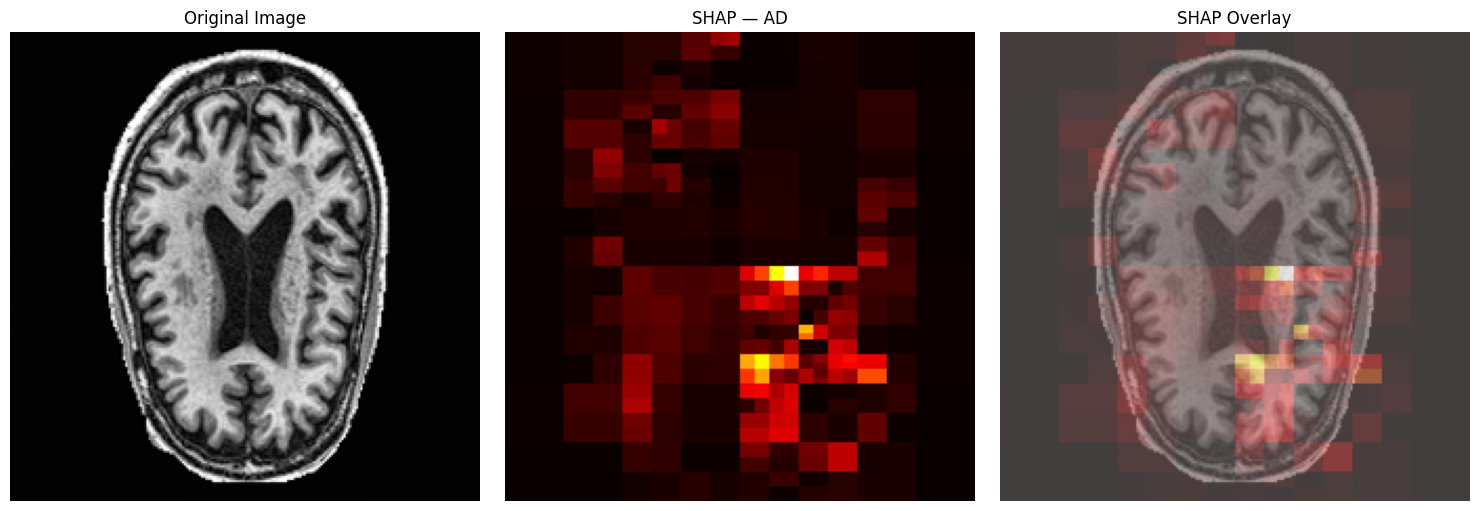

In [14]:
import shap
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

def compute_shap_explanation(image_path, pos_class_idx=0, fold_idx=0, max_evals=1000):
    pos_name = CLASS_NAMES[pos_class_idx]
    svm = all_fold_svms[pos_name][fold_idx]
    scaler = all_fold_scalers[pos_name][fold_idx]

    img = Image.open(image_path).convert("L")
    img = img.resize((IMAGE_SIZE, IMAGE_SIZE))
    img_np = np.array(img)
    img_rgb = np.stack([img_np] * 3, axis=-1).astype(np.uint8)

    extractor.to(device)
    extractor.eval()

    def predict_fn(images):
        tensors = []
        for img_arr in images:
            t = transforms.ToTensor()(img_arr).float()
            t = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)(t)
            tensors.append(t)
        batch = torch.stack(tensors).to(device)

        fc6_out = {}
        def hook_fn(module, input, output):
            fc6_out['feat'] = output.detach().cpu()

        hook = extractor.classifier[0].register_forward_hook(hook_fn)
        with torch.no_grad():
            _ = extractor(batch)
        hook.remove()

        features = fc6_out['feat'].numpy()
        features_sc = scaler.transform(features)
        probs = svm.predict_proba(features_sc)
        return probs

    masker = shap.maskers.Image("blur(32,32)", img_rgb.shape)

    explainer = shap.Explainer(predict_fn, masker,
                               output_names=["REST", pos_name])

    shap_values = explainer(
        img_rgb[np.newaxis, ...],
        max_evals=max_evals,
        batch_size=32
    )

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(img_np, cmap='gray')
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    shap_img = shap_values.values[0, :, :, :, 1]
    shap_map = np.mean(np.abs(shap_img), axis=-1)
    shap_map = (shap_map - shap_map.min()) / (shap_map.max() - shap_map.min() + 1e-8)

    axes[1].imshow(shap_map, cmap='hot')
    axes[1].set_title(f'SHAP — {pos_name}')
    axes[1].axis('off')

    axes[2].imshow(img_np, cmap='gray', alpha=0.6)
    axes[2].imshow(shap_map, cmap='hot', alpha=0.4)
    axes[2].set_title('SHAP Overlay')
    axes[2].axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(CKPT_DIR, f'shap_explanation_{pos_name}.png'), dpi=150)
    plt.show()

    return shap_values

test_image = test_entries[0][0]
shap_values = compute_shap_explanation(test_image, pos_class_idx=0, fold_idx=0, max_evals=2000)

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


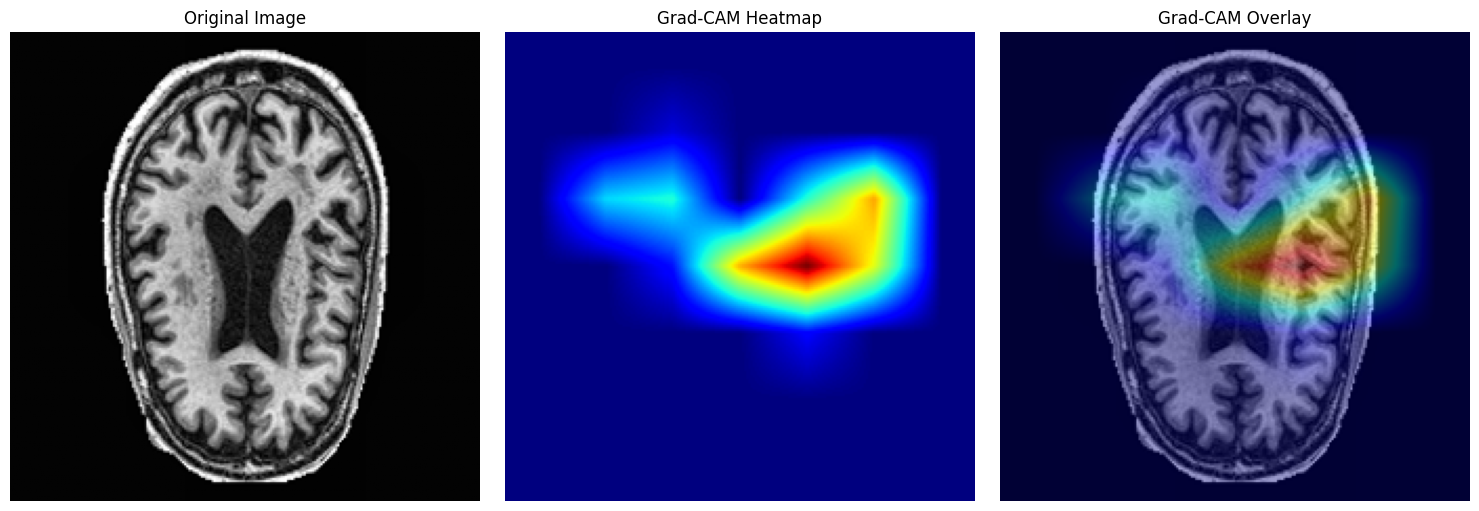

In [15]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        def forward_hook(module, input, output):
            self.activations = output.detach()
        
        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()
        
        self.forward_handle = target_layer.register_forward_hook(forward_hook)
        self.backward_handle = target_layer.register_full_backward_hook(backward_hook)
    
    def generate_cam(self, input_image, target_class=None):
        self.model.eval()
        
        output = self.model(input_image)
        
        if target_class is None:
            target_class = output.argmax(dim=1)
        
        self.model.zero_grad()
        one_hot = torch.zeros_like(output)
        one_hot[0][target_class] = 1
        output.backward(gradient=one_hot, retain_graph=True)
        
        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])
        
        for i in range(self.activations.shape[1]):
            self.activations[:, i, :, :] *= pooled_gradients[i]
        
        heatmap = torch.mean(self.activations, dim=1).squeeze()
        heatmap = F.relu(heatmap)
        heatmap /= torch.max(heatmap)
        
        return heatmap.cpu().numpy()
    
    def __del__(self):
        self.forward_handle.remove()
        self.backward_handle.remove()

def apply_gradcam(image_path, class_idx=None):
    target_layer = extractor.features[-1]  
    
    gradcam = GradCAM(extractor, target_layer)
    
    img = Image.open(image_path).convert("L")
    img = img.resize((IMAGE_SIZE, IMAGE_SIZE))
    img_tensor = transforms.ToTensor()(img).repeat(3, 1, 1).float()
    
    normalize = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    img_normalized = normalize(img_tensor).unsqueeze(0).to(device)
    img_normalized.requires_grad = True
    
    cam = gradcam.generate_cam(img_normalized, target_class=class_idx)
    
    cam_resized = cv2.resize(cam, (IMAGE_SIZE, IMAGE_SIZE))
    
    cam_resized = (cam_resized - cam_resized.min()) / (cam_resized.max() - cam_resized.min())
    
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    
    img_array = np.array(img)
    img_rgb = np.stack([img_array]*3, axis=-1)
    superimposed = heatmap * 0.4 + img_rgb * 0.6
    superimposed = superimposed.astype(np.uint8)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(img_array, cmap='gray')
    axes[0].set_title('Original Image')
    axes[0].axis('off')
    
    axes[1].imshow(cam_resized, cmap='jet')
    axes[1].set_title('Grad-CAM Heatmap')
    axes[1].axis('off')
    
    axes[2].imshow(superimposed)
    axes[2].set_title('Grad-CAM Overlay')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.savefig(os.path.join(CKPT_DIR, 'gradcam_visualization.png'), dpi=150)
    plt.show()
    
    return cam_resized

test_image = test_entries[0][0]
cam = apply_gradcam(test_image, class_idx=0)

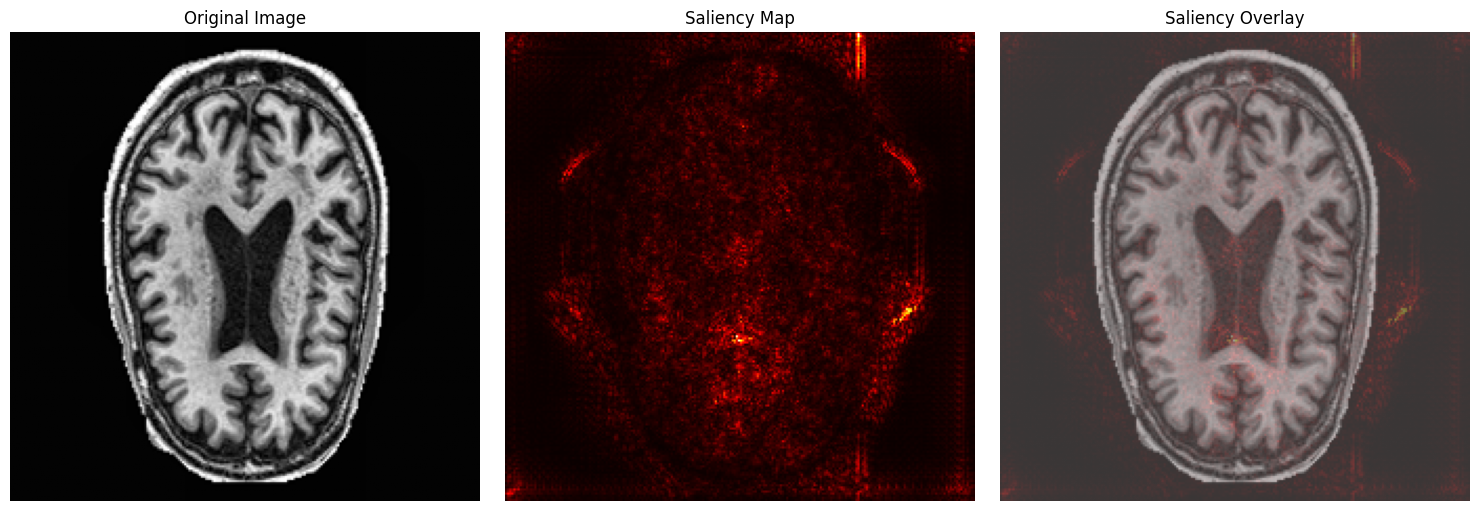

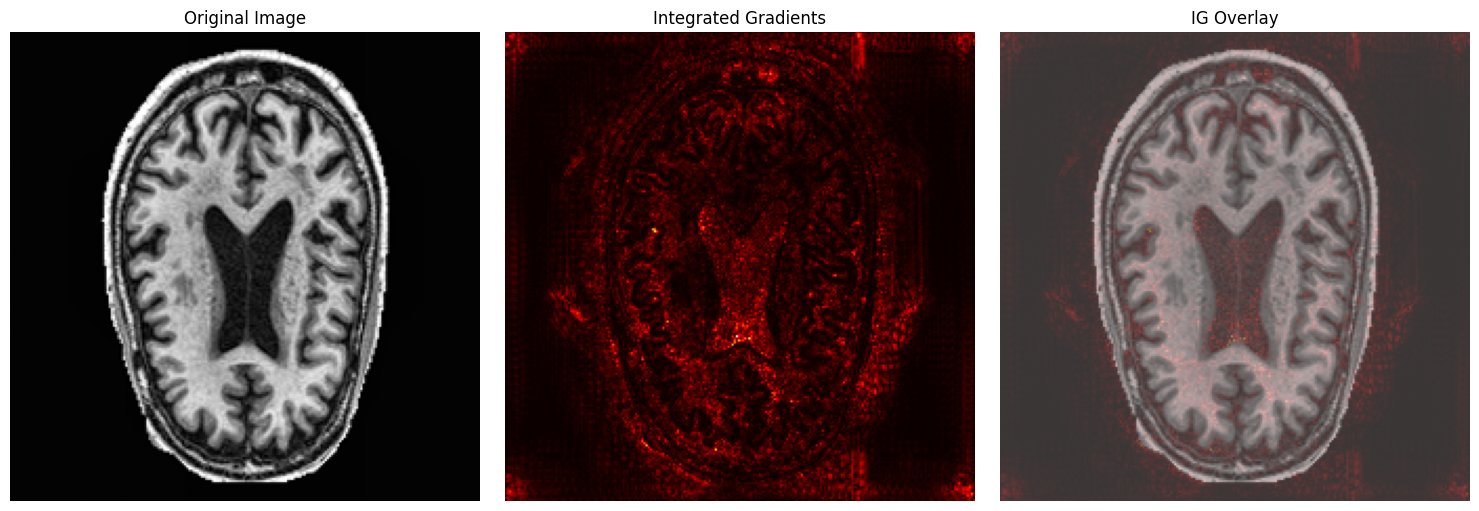

In [16]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def compute_saliency_map(image_path, pos_class_idx, fold_idx=0):
    pos_name = CLASS_NAMES[pos_class_idx]
    
    img = Image.open(image_path).convert("L")
    img = img.resize((IMAGE_SIZE, IMAGE_SIZE))
    img_tensor = transforms.ToTensor()(img).repeat(3, 1, 1).float()
    
    normalize = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    img_normalized = normalize(img_tensor).unsqueeze(0).to(device)
    img_normalized.requires_grad = True
    
    extractor.to(device)
    extractor.eval()
    
    fc6_output = {}
    def hook_fn(module, input, output):
        fc6_output['feat'] = output
    
    hook = extractor.classifier[1].register_forward_hook(hook_fn)
    _ = extractor(img_normalized)
    hook.remove()
    
    features = fc6_output['feat']
    
    score = torch.norm(features, p=2, dim=1)
    
    extractor.zero_grad()
    score.backward()
    
    saliency = img_normalized.grad.data.abs()
    saliency = saliency.squeeze(0).cpu().numpy()
    
    saliency_map = np.max(saliency, axis=0)
    
    saliency_map = (saliency_map - saliency_map.min()) / (saliency_map.max() - saliency_map.min())
    
    img_array = np.array(img)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(img_array, cmap='gray')
    axes[0].set_title('Original Image')
    axes[0].axis('off')
    
    axes[1].imshow(saliency_map, cmap='hot')
    axes[1].set_title('Saliency Map')
    axes[1].axis('off')
    
    axes[2].imshow(img_array, cmap='gray', alpha=0.7)
    axes[2].imshow(saliency_map, cmap='hot', alpha=0.3)
    axes[2].set_title('Saliency Overlay')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.savefig(os.path.join(CKPT_DIR, f'saliency_map_{pos_name}.png'), dpi=150)
    plt.show()
    
    return saliency_map

def compute_integrated_gradients(image_path, pos_class_idx, fold_idx=0, steps=50):
    pos_name = CLASS_NAMES[pos_class_idx]
    
    img = Image.open(image_path).convert("L")
    img = img.resize((IMAGE_SIZE, IMAGE_SIZE))
    img_tensor = transforms.ToTensor()(img).repeat(3, 1, 1).float()
    
    normalize = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    img_normalized = normalize(img_tensor).unsqueeze(0).to(device)
    
    baseline = torch.zeros_like(img_normalized).to(device)
    
    alphas = torch.linspace(0, 1, steps).to(device)
    
    integrated_grads = torch.zeros_like(img_normalized)
    
    extractor.to(device)
    extractor.eval()
    
    for alpha in alphas:
        interpolated = baseline + alpha * (img_normalized - baseline)
        interpolated.requires_grad = True
        
        fc6_output = {}
        def hook_fn(module, input, output):
            fc6_output['feat'] = output
        
        hook = extractor.classifier[1].register_forward_hook(hook_fn)
        _ = extractor(interpolated)
        hook.remove()
        
        features = fc6_output['feat']
        score = torch.norm(features, p=2, dim=1)
        
        extractor.zero_grad()
        if interpolated.grad is not None:
            interpolated.grad.zero_()
        score.backward()
        
        integrated_grads += interpolated.grad.data
    
    integrated_grads = integrated_grads / steps
    integrated_grads = integrated_grads * (img_normalized - baseline)
    
    saliency = integrated_grads.abs().squeeze(0).cpu().numpy()
    saliency_map = np.max(saliency, axis=0)
    saliency_map = (saliency_map - saliency_map.min()) / (saliency_map.max() - saliency_map.min())
    
    img_array = np.array(img)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(img_array, cmap='gray')
    axes[0].set_title('Original Image')
    axes[0].axis('off')
    
    axes[1].imshow(saliency_map, cmap='hot')
    axes[1].set_title('Integrated Gradients')
    axes[1].axis('off')
    
    axes[2].imshow(img_array, cmap='gray', alpha=0.7)
    axes[2].imshow(saliency_map, cmap='hot', alpha=0.3)
    axes[2].set_title('IG Overlay')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.savefig(os.path.join(CKPT_DIR, f'integrated_gradients_{pos_name}.png'), dpi=150)
    plt.show()
    
    return saliency_map

test_image = test_entries[0][0]
saliency = compute_saliency_map(test_image, pos_class_idx=0, fold_idx=0)
ig_saliency = compute_integrated_gradients(test_image, pos_class_idx=0, fold_idx=0)

In [18]:
import os
import shutil
from IPython.display import FileLink, display

print("="*60)
print("Packaging all files into a single ZIP...")
print("="*60)

import joblib
vgg19_save_path = os.path.join(CKPT_DIR, 'vgg19_model_final.pkl')
joblib.dump(svm, vgg19_save_path)

zip_path = "/kaggle/temp/all_project_outputs.zip"
os.makedirs("/kaggle/temp", exist_ok=True)
shutil.make_archive(zip_path.replace('.zip', ''), 'zip', '/kaggle/working')

final_zip_path = "/kaggle/working/all_project_outputs_vgg19.zip"
shutil.move(zip_path, final_zip_path)

print("\n✅ Done! Click the link below to download everything in one file:")
display(FileLink("all_project_outputs_vgg19.zip"))

Packaging all files into a single ZIP...

✅ Done! Click the link below to download everything in one file:


/kaggle/working/all_project_outputs_vgg19.zip